## Notebook: Foundational ML Concepts

Designed by: [Tirtharaj Dash](https://tirtharajdash.github.io) | March 2026

This notebook builds intuition for the core concepts that underpin every ML model you will use in practice. Each section has a brief theoretical summary followed by a hands-on demonstration using synthetic or real sensor-like data.

### Topics
1. The learning problem: data, features, targets
2. Loss functions
3. Underfitting and overfitting
4. Bias–variance tradeoff
5. Regularisation
6. The curse of dimensionality
7. Feature scaling
8. Cross-validation
9. Class imbalance
10. Learning curves

**References**  
- Hastie, T., Tibshirani, R., Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Springer. [Free PDF](https://hastie.su.domains/ElemStatLearn/)  
- Bishop, C.M. (2006). *Pattern Recognition and Machine Learning*. Springer.  
- Goodfellow, I., Bengio, Y., Courville, A. (2016). *Deep Learning*. MIT Press. [Free online](https://www.deeplearningbook.org)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import (
    train_test_split, KFold, cross_val_score, learning_curve
)
from sklearn.metrics import mean_squared_error
from sklearn.datasets import make_classification
from sklearn.neighbors import KNeighborsClassifier
from sklearn.utils import resample

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
np.random.seed(42)

### 1. The Learning Problem

#### 1.1 Setup

Supervised learning assumes data is drawn i.i.d. from an unknown joint distribution $p(\mathbf{x}, y)$. Given a training set
$$\mathcal{D} = \{(\mathbf{x}_i, y_i)\}_{i=1}^n$$
we want to learn a function $f: \mathbb{R}^d \to \mathcal{Y}$ that generalises to unseen inputs drawn from the same distribution.

In the predictive maintenance context:
- $\mathbf{x}_i$ = sensor readings at cycle $i$ (temperature, pressure, torque, …)
- $y_i$ = failure label (classification) or remaining useful life (regression)

#### 1.2 Regression vs. Classification

| Task | Target $y$ | Example |
|---|---|---|
| Regression | $y \in \mathbb{R}$ | Predict RUL in cycles |
| Binary classification | $y \in \{0, 1\}$ | Predict failure / no-failure |
| Multi-class | $y \in \{1,\ldots,K\}$ | Predict failure mode |

#### 1.3 True risk vs. empirical risk

The true risk (what we really want to minimise) is:
$$R(f) = \mathbb{E}_{(\mathbf{x},y) \sim p}[\ell(f(\mathbf{x}), y)]$$

Since $p$ is unknown, we minimise the **empirical risk** on training data:
$$\hat{R}(f) = \frac{1}{n}\sum_{i=1}^n \ell(f(\mathbf{x}_i), y_i)$$

The gap $R(f) - \hat{R}(f)$ is the **generalisation error** — the central concern of ML.

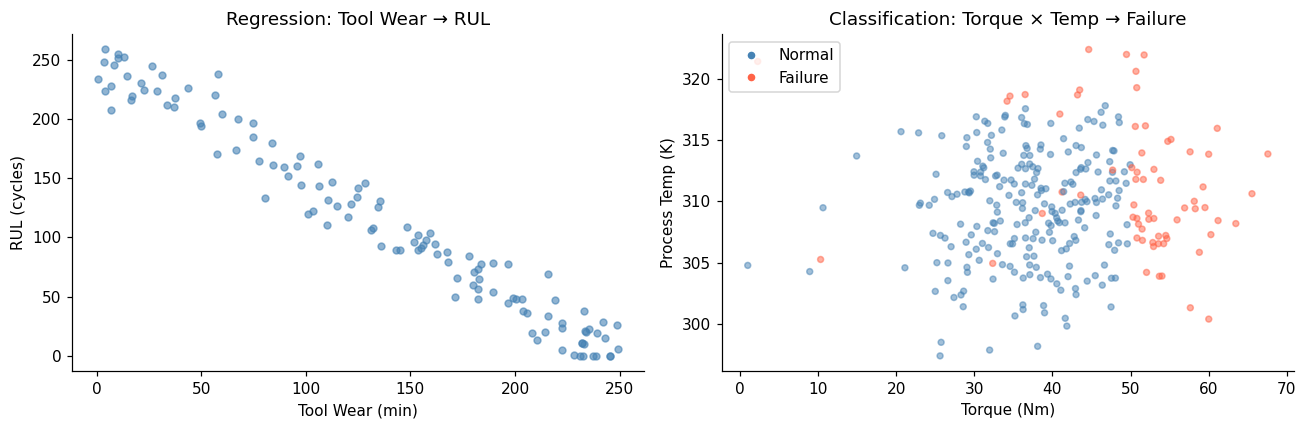

In [2]:
# Demonstration: visualise a regression and a classification problem
# using synthetic sensor-like data

rng = np.random.default_rng(0)

# Regression: tool wear -> RUL
wear = rng.uniform(0, 250, 120)
rul  = 250 - wear + rng.normal(0, 15, 120)
rul  = np.clip(rul, 0, None)

# Classification: torque x temperature -> failure
n = 300
torque = rng.normal(40, 10, n)
temp   = rng.normal(310, 5, n)
label  = ((torque > 50) | (temp > 318)).astype(int)
label += rng.integers(0, 2, n) * (rng.uniform(size=n) < 0.05)  # 5% noise
label  = np.clip(label, 0, 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(wear, rul, s=20, alpha=0.6, color='steelblue')
axes[0].set_xlabel('Tool Wear (min)')
axes[0].set_ylabel('RUL (cycles)')
axes[0].set_title('Regression: Tool Wear → RUL')

colors = ['steelblue' if l == 0 else 'tomato' for l in label]
axes[1].scatter(torque, temp, s=15, alpha=0.5, c=colors)
axes[1].set_xlabel('Torque (Nm)')
axes[1].set_ylabel('Process Temp (K)')
axes[1].set_title('Classification: Torque × Temp → Failure')
axes[1].legend(
    handles=[
        plt.Line2D([0],[0],marker='o',color='w',markerfacecolor='steelblue',label='Normal'),
        plt.Line2D([0],[0],marker='o',color='w',markerfacecolor='tomato',label='Failure')
    ], loc='upper left'
)

plt.tight_layout()
plt.show()

### 2. Loss Functions

A loss function $\ell(\hat{y}, y)$ measures the cost of predicting $\hat{y}$ when the truth is $y$.

#### 2.1 Regression losses

| Loss | Formula | Property |
|---|---|---|
| Squared error (L2) | $(\hat{y} - y)^2$ | Penalises large errors heavily; sensitive to outliers |
| Absolute error (L1) | $|\hat{y} - y|$ | Robust to outliers; not differentiable at 0 |
| Huber | $\frac{1}{2}(\hat{y}-y)^2$ if $|e|\le\delta$, else $\delta|e|-\frac{\delta^2}{2}$ | Best of both; used in GBR |

#### 2.2 Classification loss

**Binary cross-entropy** (log loss):
$$\ell(\hat{p}, y) = -\left[y \log \hat{p} + (1-y)\log(1-\hat{p})\right]$$

where $\hat{p} = P(y=1 \mid \mathbf{x})$. This is the loss minimised by logistic regression.

#### 2.3 Why loss choice matters

In RUL prediction, **late predictions** (predicting more life remaining than there actually is) are more dangerous than early predictions. The PHM08 scoring function uses an asymmetric exponential penalty:
$$s_i = \begin{cases} e^{-e_i/13} - 1 & e_i < 0 \\ e^{e_i/10} - 1 & e_i \ge 0 \end{cases}, \quad e_i = \hat{y}_i - y_i$$

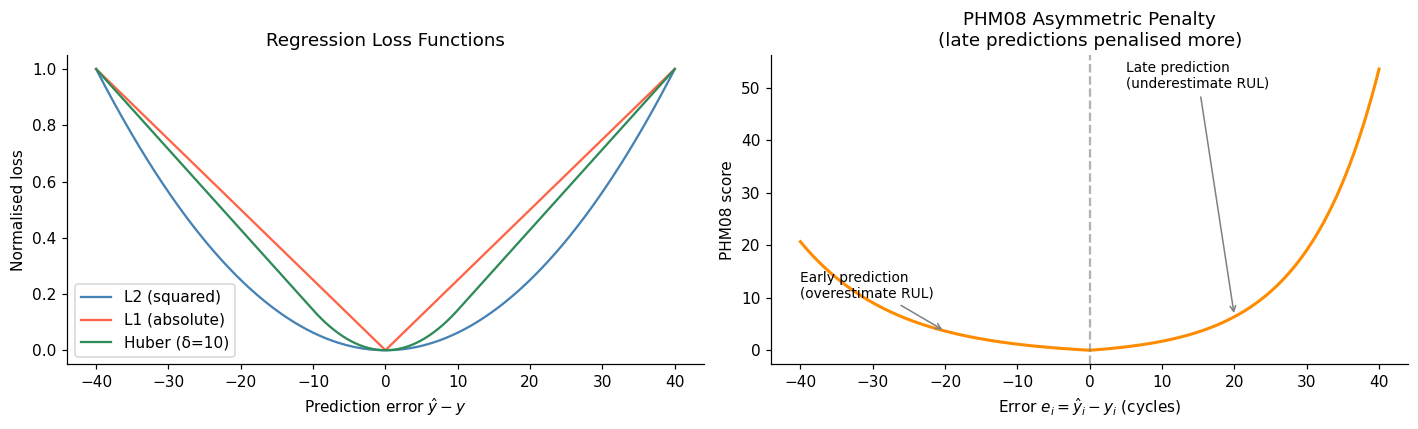

In [3]:
errors = np.linspace(-40, 40, 400)

l2    = errors**2
l1    = np.abs(errors)
delta = 10
huber = np.where(np.abs(errors) <= delta,
                 0.5 * errors**2,
                 delta * np.abs(errors) - 0.5 * delta**2)
# PHM08 asymmetric score
phm   = np.where(errors < 0,
                 np.exp(-errors / 13) - 1,
                 np.exp(errors / 10) - 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(errors, l2 / l2.max(), label='L2 (squared)', color='steelblue')
axes[0].plot(errors, l1 / l1.max(), label='L1 (absolute)', color='tomato')
axes[0].plot(errors, huber / huber.max(), label=f'Huber (δ={delta})', color='seagreen')
axes[0].set_xlabel('Prediction error $\\hat{y} - y$')
axes[0].set_ylabel('Normalised loss')
axes[0].set_title('Regression Loss Functions')
axes[0].legend()

axes[1].plot(errors, phm, color='darkorange', linewidth=2)
axes[1].axvline(0, color='gray', linestyle='--', alpha=0.6)
axes[1].set_xlabel('Error $e_i = \\hat{y}_i - y_i$ (cycles)')
axes[1].set_ylabel('PHM08 score')
axes[1].set_title('PHM08 Asymmetric Penalty\n(late predictions penalised more)')
axes[1].annotate('Late prediction\n(underestimate RUL)', xy=(20, phm[np.searchsorted(errors,20)]),
                 xytext=(5, 50), arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9)
axes[1].annotate('Early prediction\n(overestimate RUL)', xy=(-20, phm[np.searchsorted(errors,-20)]),
                 xytext=(-40, 10), arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9)

plt.tight_layout()
plt.show()

### 3. Underfitting and Overfitting

#### Theory

Every ML model has a **capacity** — its ability to fit complex functions. Capacity is controlled by hyperparameters such as polynomial degree, number of trees, or network depth.

| Regime | Train error | Test error | Diagnosis |
|---|---|---|---|
| **Underfitting** | High | High | Model too simple; cannot capture the pattern |
| **Good fit** | Low | Low | Model capacity matches data complexity |
| **Overfitting** | Very low | High | Model memorises training noise |

As model capacity increases:
- Training error monotonically **decreases**
- Test error forms a **U-shape** — the classic bias–variance tradeoff curve

**Engineering analogy**: fitting a 1st-degree polynomial to a nonlinear degradation curve (underfitting) vs. fitting a degree-20 polynomial that wiggles through every noisy measurement (overfitting).

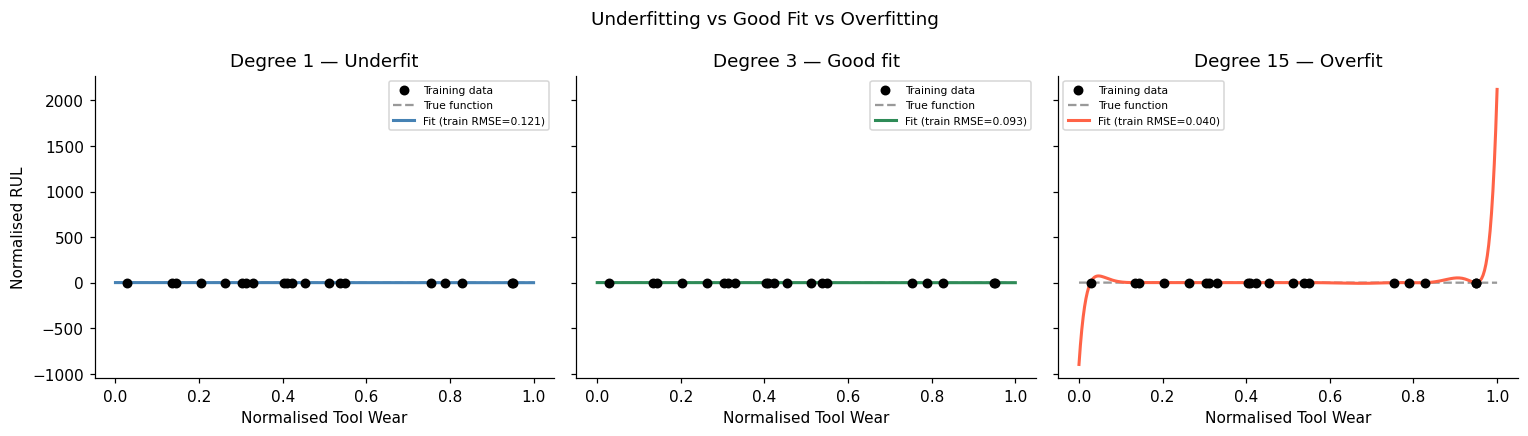

In [4]:
# True degradation: RUL ~ quadratic in tool wear, with noise
rng = np.random.default_rng(1)

def true_fn(x):
    return 1.0 - x**2

n_train = 20
X_train = np.sort(rng.uniform(0, 1, n_train))
y_train = true_fn(X_train) + rng.normal(0, 0.08, n_train)

X_plot  = np.linspace(0, 1, 300)
degrees = [1, 3, 15]
titles  = ['Degree 1 — Underfit', 'Degree 3 — Good fit', 'Degree 15 — Overfit']
colors  = ['steelblue', 'seagreen', 'tomato']

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, deg, title, col in zip(axes, degrees, titles, colors):
    model = make_pipeline(PolynomialFeatures(deg), LinearRegression())
    model.fit(X_train.reshape(-1,1), y_train)
    y_pred = model.predict(X_plot.reshape(-1,1))
    train_rmse = np.sqrt(mean_squared_error(y_train, model.predict(X_train.reshape(-1,1))))

    ax.scatter(X_train, y_train, s=30, color='black', zorder=5, label='Training data')
    ax.plot(X_plot, true_fn(X_plot), 'k--', alpha=0.4, label='True function')
    ax.plot(X_plot, y_pred, color=col, linewidth=2, label=f'Fit (train RMSE={train_rmse:.3f})')
    ax.set_title(title)
    ax.set_xlabel('Normalised Tool Wear')
    ax.legend(fontsize=7)

axes[0].set_ylabel('Normalised RUL')
plt.suptitle('Underfitting vs Good Fit vs Overfitting', fontsize=12)
plt.tight_layout()
plt.show()

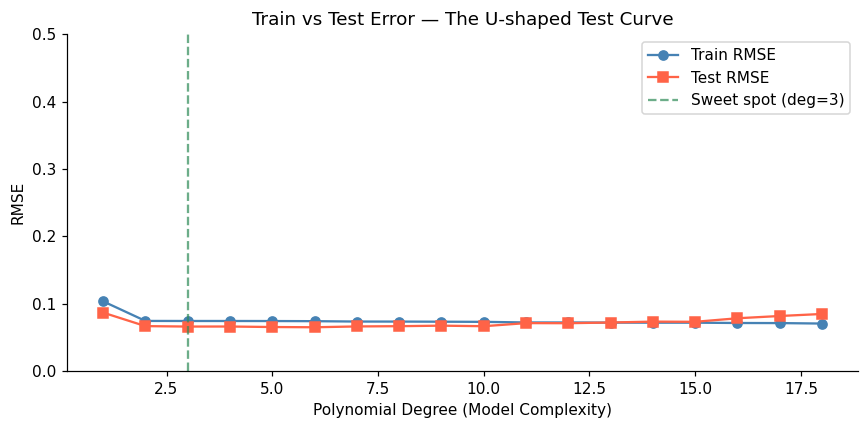

In [5]:
# Train vs test error as a function of polynomial degree
rng = np.random.default_rng(1)
X_all = np.sort(rng.uniform(0, 1, 200))
y_all = true_fn(X_all) + rng.normal(0, 0.08, 200)
X_tr, X_te, y_tr, y_te = train_test_split(
    X_all.reshape(-1,1), y_all, test_size=0.4, random_state=0
)

max_deg = 18
train_errs, test_errs = [], []
for d in range(1, max_deg+1):
    m = make_pipeline(PolynomialFeatures(d), LinearRegression())
    m.fit(X_tr, y_tr)
    train_errs.append(np.sqrt(mean_squared_error(y_tr, m.predict(X_tr))))
    test_errs.append(np.sqrt(mean_squared_error(y_te, m.predict(X_te))))

degrees = range(1, max_deg+1)
plt.figure(figsize=(8, 4))
plt.plot(degrees, train_errs, 'o-', color='steelblue', label='Train RMSE')
plt.plot(degrees, test_errs,  's-', color='tomato',    label='Test RMSE')
plt.axvline(3, color='seagreen', linestyle='--', alpha=0.7, label='Sweet spot (deg=3)')
plt.xlabel('Polynomial Degree (Model Complexity)')
plt.ylabel('RMSE')
plt.title('Train vs Test Error — The U-shaped Test Curve')
plt.legend()
plt.ylim(0, 0.5)
plt.tight_layout()
plt.show()

### 4. Bias–Variance Tradeoff

#### Theory

For a fixed test point $\mathbf{x}$, the expected squared error of a model $\hat{f}$ trained on random training sets $\mathcal{D}$ decomposes as:

$$\mathbb{E}_{\mathcal{D}}\left[(y - \hat{f}(\mathbf{x}))^2\right]
= \underbrace{\left(f^*(\mathbf{x}) - \mathbb{E}_{\mathcal{D}}[\hat{f}(\mathbf{x})]\right)^2}_{\text{Bias}^2}
+ \underbrace{\mathbb{E}_{\mathcal{D}}\left[\left(\hat{f}(\mathbf{x}) - \mathbb{E}_{\mathcal{D}}[\hat{f}(\mathbf{x})]\right)^2\right]}_{\text{Variance}}
+ \underbrace{\sigma^2}_{\text{Irreducible noise}}$$

- **Bias**: systematic error — how far off the average prediction is from truth. High for simple models.
- **Variance**: sensitivity to the specific training set drawn. High for complex models.
- **Irreducible noise** $\sigma^2$: inherent randomness in the data. Cannot be reduced by any model.

**Key insight**: you cannot simultaneously minimise both bias and variance. Increasing model complexity reduces bias but increases variance.

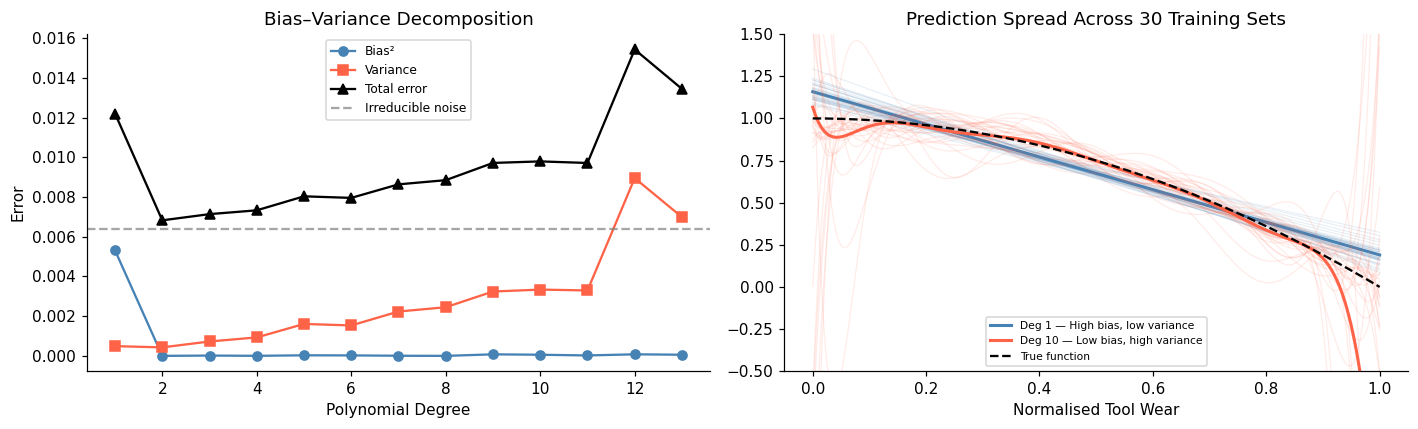

In [6]:
# Empirical bias-variance decomposition across polynomial degrees
# For each degree: train many models on different bootstrap samples,
# measure spread of predictions at a fixed test point.

rng = np.random.default_rng(7)
N_DATASETS = 80
n_train    = 25
x_test     = np.array([[0.6]])
y_true_at_test = true_fn(0.6)
NOISE_STD  = 0.08

degrees  = list(range(1, 14))
biases2, variances, total_errs = [], [], []

for deg in degrees:
    preds_at_test = []
    for _ in range(N_DATASETS):
        Xd = rng.uniform(0, 1, n_train).reshape(-1,1)
        yd = true_fn(Xd.ravel()) + rng.normal(0, NOISE_STD, n_train)
        m  = make_pipeline(PolynomialFeatures(deg), LinearRegression())
        m.fit(Xd, yd)
        preds_at_test.append(m.predict(x_test)[0])
    preds = np.array(preds_at_test)
    mean_pred = preds.mean()
    bias2  = (mean_pred - y_true_at_test)**2
    var    = preds.var()
    biases2.append(bias2)
    variances.append(var)
    total_errs.append(bias2 + var + NOISE_STD**2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(degrees, biases2,    'o-', color='steelblue', label='Bias²')
axes[0].plot(degrees, variances,  's-', color='tomato',    label='Variance')
axes[0].plot(degrees, total_errs, '^-', color='black',     label='Total error')
axes[0].axhline(NOISE_STD**2, linestyle='--', color='gray', alpha=0.7, label='Irreducible noise')
axes[0].set_xlabel('Polynomial Degree')
axes[0].set_ylabel('Error')
axes[0].set_title('Bias–Variance Decomposition')
axes[0].legend(fontsize=8)

# Visualise prediction spread for degree 1 (high bias) vs degree 10 (high variance)
X_plot = np.linspace(0, 1, 200).reshape(-1,1)
for ax, deg, label, col in [
    (axes[1], 1,  'Deg 1 — High bias, low variance', 'steelblue'),
    (axes[1], 10, 'Deg 10 — Low bias, high variance', 'tomato')
]:
    sample_preds = []
    for _ in range(30):
        Xd = rng.uniform(0, 1, n_train).reshape(-1,1)
        yd = true_fn(Xd.ravel()) + rng.normal(0, NOISE_STD, n_train)
        m  = make_pipeline(PolynomialFeatures(deg), LinearRegression())
        m.fit(Xd, yd)
        sample_preds.append(m.predict(X_plot))
    sample_preds = np.array(sample_preds)
    for p in sample_preds:
        ax.plot(X_plot, p, alpha=0.12, color=col, linewidth=0.8)
    ax.plot(X_plot, sample_preds.mean(axis=0), color=col, linewidth=2, label=label)

axes[1].plot(X_plot, true_fn(X_plot.ravel()), 'k--', linewidth=1.5, label='True function')
axes[1].set_xlabel('Normalised Tool Wear')
axes[1].set_title('Prediction Spread Across 30 Training Sets')
axes[1].legend(fontsize=7)
axes[1].set_ylim(-0.5, 1.5)

plt.tight_layout()
plt.show()

### 5. Regularisation

#### Theory

Regularisation adds a penalty on model complexity to the loss, discouraging overfitting:
$$\mathcal{L}_{\text{reg}}(\mathbf{w}) = \underbrace{\frac{1}{n}\sum_{i=1}^n \ell(\hat{y}_i, y_i)}_{\text{data fit}} + \underbrace{\lambda\, \Omega(\mathbf{w})}_{\text{complexity penalty}}$$

| Method | Penalty $\Omega(\mathbf{w})$ | Effect |
|---|---|---|
| Ridge (L2) | $\|\mathbf{w}\|_2^2 = \sum_j w_j^2$ | Shrinks all weights; never sets to zero |
| Lasso (L1) | $\|\mathbf{w}\|_1 = \sum_j |w_j|$ | Sparse solutions; irrelevant features → 0 |
| Elastic Net | $\alpha\|\mathbf{w}\|_1 + (1-\alpha)\|\mathbf{w}\|_2^2$ | Combines both |

**Interpretation for engineers**: regularisation is like adding a prior belief that the true model is "simple" — sensors should not have wildly large influence coefficients unless the data strongly supports it.

The hyperparameter $\lambda$ controls the bias–variance tradeoff:
- $\lambda \to 0$: no regularisation, pure data fit (high variance)
- $\lambda \to \infty$: all weights → 0, model predicts mean (high bias)

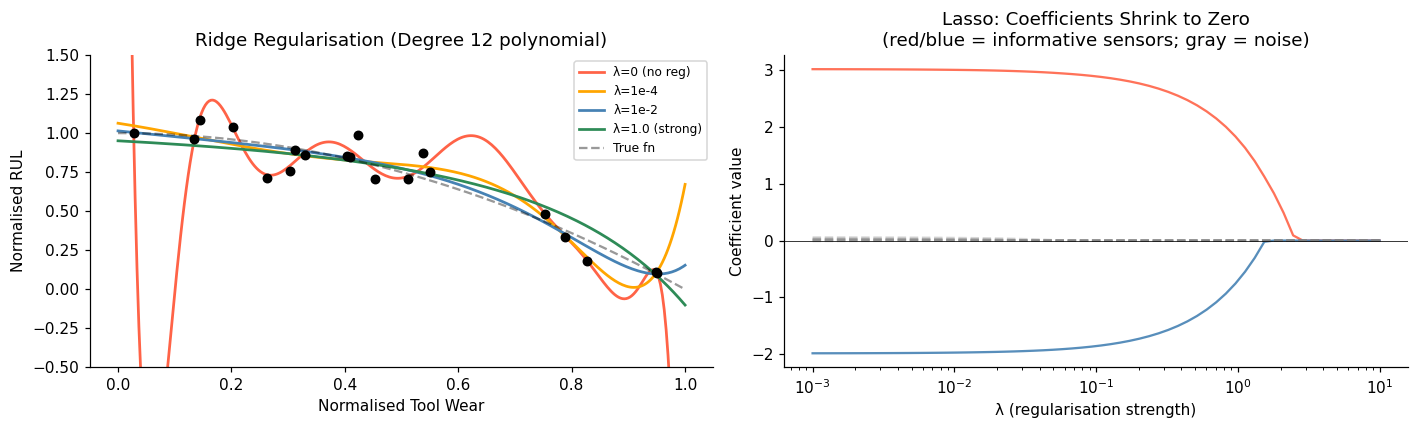

In [7]:
# Effect of Ridge regularisation on a high-degree polynomial
rng = np.random.default_rng(1)
n   = 20
X_tr = np.sort(rng.uniform(0, 1, n)).reshape(-1, 1)
y_tr = true_fn(X_tr.ravel()) + rng.normal(0, 0.08, n)
X_pl = np.linspace(0, 1, 300).reshape(-1, 1)

deg     = 12
lambdas = [0.0, 1e-4, 1e-2, 1.0]
labels  = ['λ=0 (no reg)', 'λ=1e-4', 'λ=1e-2', 'λ=1.0 (strong)']
colors  = ['tomato', 'orange', 'steelblue', 'seagreen']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for lam, lab, col in zip(lambdas, labels, colors):
    if lam == 0.0:
        m = make_pipeline(PolynomialFeatures(deg), LinearRegression())
    else:
        m = make_pipeline(PolynomialFeatures(deg), Ridge(alpha=lam))
    m.fit(X_tr, y_tr)
    axes[0].plot(X_pl, m.predict(X_pl), label=lab, color=col, linewidth=1.8)

axes[0].scatter(X_tr, y_tr, s=30, color='black', zorder=5)
axes[0].plot(X_pl, true_fn(X_pl.ravel()), 'k--', alpha=0.4, linewidth=1.5, label='True fn')
axes[0].set_ylim(-0.5, 1.5)
axes[0].set_xlabel('Normalised Tool Wear')
axes[0].set_ylabel('Normalised RUL')
axes[0].set_title(f'Ridge Regularisation (Degree {deg} polynomial)')
axes[0].legend(fontsize=8)

# Lasso: sparsity effect on feature coefficients
rng2  = np.random.default_rng(3)
n2    = 200
# 2 informative sensors + 8 noise sensors
X_sp  = rng2.normal(0, 1, (n2, 10))
y_sp  = 3.0 * X_sp[:,0] - 2.0 * X_sp[:,1] + rng2.normal(0, 0.5, n2)

lasso_coefs, ridge_coefs, alphas = [], [], np.logspace(-3, 1, 60)
for a in alphas:
    lasso_coefs.append(Lasso(alpha=a, max_iter=5000).fit(X_sp, y_sp).coef_)
    ridge_coefs.append(Ridge(alpha=a).fit(X_sp, y_sp).coef_)

lasso_coefs = np.array(lasso_coefs)
ridge_coefs = np.array(ridge_coefs)

for j in range(10):
    style = '-' if j < 2 else '--'
    alpha_val = 0.9 if j < 2 else 0.3
    axes[1].plot(alphas, lasso_coefs[:,j], style, alpha=alpha_val,
                 color='tomato' if j==0 else ('steelblue' if j==1 else 'gray'))

axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_xscale('log')
axes[1].set_xlabel('λ (regularisation strength)')
axes[1].set_ylabel('Coefficient value')
axes[1].set_title('Lasso: Coefficients Shrink to Zero\n(red/blue = informative sensors; gray = noise)')

plt.tight_layout()
plt.show()

### 6. The Curse of Dimensionality

#### Theory

As the number of features $d$ grows, the volume of the input space grows exponentially. For a fixed number of training points $n$, the data become increasingly **sparse** in high dimensions.

**Consequence for nearest-neighbour reasoning**: to capture a fixed fraction $r$ of the data volume in $d$ dimensions, the edge length of a hypercube must be:
$$\ell(d) = r^{1/d}$$

For $r = 0.01$ (1% of data): $\ell(1) = 0.01$, $\ell(10) \approx 0.63$, $\ell(100) \approx 0.955$ — nearly the entire space.

**Practical consequences**:
- Distance-based methods (k-NN) degrade in high $d$
- More features ≠ more information; irrelevant features add noise
- Need exponentially more data to maintain sample density
- Motivates **feature selection** and **dimensionality reduction** (e.g., PCA)

In CMAPSS: 21 sensors, but several are near-constant (zero variance). Removing them before modelling improves performance.

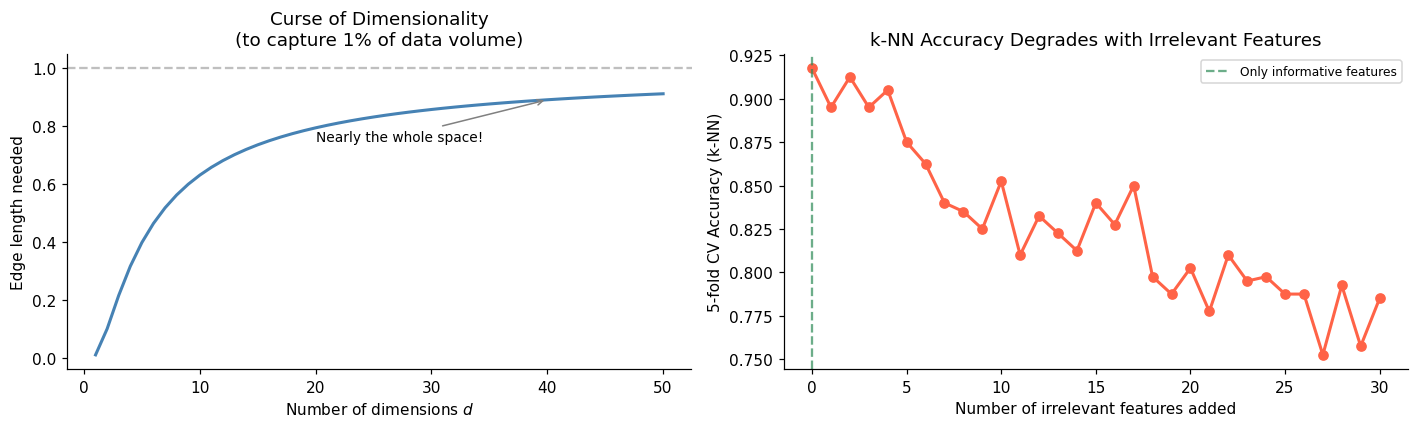

In [8]:
# Demonstration 1: fraction of volume needed grows with d
dims = np.arange(1, 51)
r    = 0.01  # capture 1% of training data
edge = r ** (1.0 / dims)

# Demonstration 2: k-NN accuracy degrades as irrelevant features are added
rng = np.random.default_rng(5)
n_samples    = 400
max_noise_d  = 30

# 2 informative features
X_base, y_cls = make_classification(
    n_samples=n_samples, n_features=2, n_informative=2,
    n_redundant=0, n_clusters_per_class=1, random_state=5
)
knn_accs = []
for extra_d in range(0, max_noise_d + 1):
    X_aug = np.hstack([X_base, rng.normal(0, 1, (n_samples, extra_d))]) if extra_d > 0 else X_base
    scores = cross_val_score(KNeighborsClassifier(n_neighbors=5), X_aug, y_cls, cv=5)
    knn_accs.append(scores.mean())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(dims, edge, color='steelblue', linewidth=2)
axes[0].axhline(1.0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Number of dimensions $d$')
axes[0].set_ylabel('Edge length needed')
axes[0].set_title('Curse of Dimensionality\n(to capture 1% of data volume)')
axes[0].annotate('Nearly the whole space!', xy=(40, edge[39]),
                 xytext=(20, 0.75), arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9)

axes[1].plot(range(0, max_noise_d+1), knn_accs, 'o-', color='tomato', linewidth=2)
axes[1].set_xlabel('Number of irrelevant features added')
axes[1].set_ylabel('5-fold CV Accuracy (k-NN)')
axes[1].set_title('k-NN Accuracy Degrades with Irrelevant Features')
axes[1].axvline(0, color='seagreen', linestyle='--', alpha=0.7, label='Only informative features')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### 7. Feature Scaling

#### Theory

Many ML algorithms are sensitive to the scale of input features. Features with large numeric ranges dominate distance computations and gradient updates.

**Standardisation** (Z-score normalisation):
$$x' = \frac{x - \mu}{\sigma}$$
Transforms to zero mean and unit variance. Appropriate when data is approximately Gaussian.

**Min-max normalisation**:
$$x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}} \in [0, 1]$$
Preserves distribution shape. Used in CMAPSS Notebook 2.

**Critical rule**: fit the scaler **only on training data**, then apply (transform) to test data:
```python
scaler.fit(X_train)          # learn mu, sigma from train only
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)   # apply same transform to test
```
Fitting on the full dataset before splitting leaks test statistics into training — a subtle but common error.

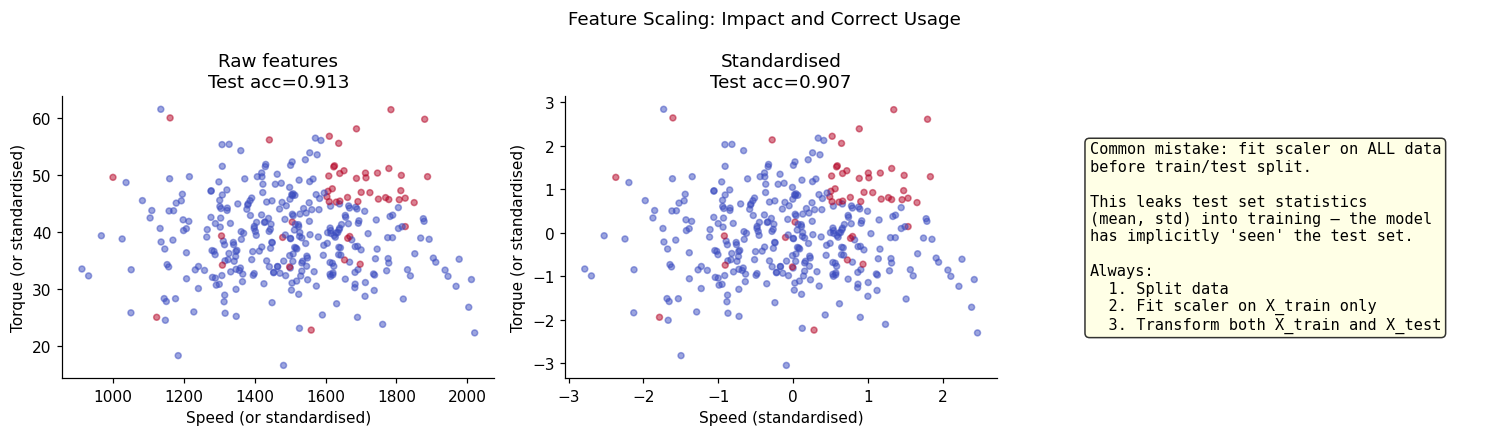

Accuracy without scaling: 0.9133
Accuracy with scaling:    0.9067


In [9]:
# Sensors with very different scales: logistic regression with/without scaling
rng = np.random.default_rng(9)
n   = 500

# Feature 1: rotational speed (hundreds to thousands)
# Feature 2: torque (tens)
speed  = rng.normal(1500, 200, n)
torque = rng.normal(40, 8, n)
label  = ((speed > 1600) & (torque > 45)).astype(int)
label  = np.where(rng.uniform(size=n) < 0.05, 1 - label, label)  # 5% noise

X = np.column_stack([speed, torque])
X_tr, X_te, y_tr, y_te = train_test_split(X, label, test_size=0.3, random_state=0)

# Without scaling
lr_raw = LogisticRegression(max_iter=200, random_state=0)
lr_raw.fit(X_tr, y_tr)
acc_raw = lr_raw.score(X_te, y_te)

# With standardisation
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)   # fit ONLY on train
X_te_s = scaler.transform(X_te)       # apply to test
lr_scl = LogisticRegression(max_iter=200, random_state=0)
lr_scl.fit(X_tr_s, y_tr)
acc_scl = lr_scl.score(X_te_s, y_te)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, Xplot, title in [
    (axes[0], X_tr, f'Raw features\nTest acc={acc_raw:.3f}'),
    (axes[1], X_tr_s, f'Standardised\nTest acc={acc_scl:.3f}')
]:
    sc = ax.scatter(Xplot[:,0], Xplot[:,1], c=y_tr,
                    cmap='coolwarm', alpha=0.5, s=15)
    ax.set_title(title)
    ax.set_xlabel('Speed (or standardised)' if 'Raw' in title else 'Speed (standardised)')
    ax.set_ylabel('Torque (or standardised)')

# Show the leakage problem
axes[2].axis('off')
msg = (
    "Common mistake: fit scaler on ALL data\n"
    "before train/test split.\n\n"
    "This leaks test set statistics\n"
    "(mean, std) into training — the model\n"
    "has implicitly 'seen' the test set.\n\n"
    "Always:\n"
    "  1. Split data\n"
    "  2. Fit scaler on X_train only\n"
    "  3. Transform both X_train and X_test"
)
axes[2].text(0.05, 0.5, msg, transform=axes[2].transAxes,
             fontsize=10, va='center', family='monospace',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('Feature Scaling: Impact and Correct Usage', fontsize=12)
plt.tight_layout()
plt.show()
print(f'Accuracy without scaling: {acc_raw:.4f}')
print(f'Accuracy with scaling:    {acc_scl:.4f}')

### 8. Cross-Validation

#### Theory

A single train/test split gives a noisy estimate of generalisation error, depending on which samples happen to end up in each set. **$k$-fold cross-validation** gives a more reliable estimate by averaging over $k$ different splits.

**Algorithm**:
1. Partition data into $k$ equal folds $F_1, \ldots, F_k$.
2. For $i = 1, \ldots, k$: train on $\mathcal{D} \setminus F_i$, evaluate on $F_i$.
3. Report mean and std of the $k$ scores.

$$\text{CV score} = \frac{1}{k}\sum_{i=1}^k \text{score}_i$$

Typical choice: $k = 5$ or $k = 10$.

**Why not $k = n$ (leave-one-out)?** Very low bias but high variance; also expensive for large $n$.

**Important for time series / RUL**: standard $k$-fold randomly shuffles data, which **breaks temporal order**. Use a unit-level split instead (as in Notebook 2): hold out entire engine units as the test set, never individual cycles.

/tmp/ipykernel_522882/802243016.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


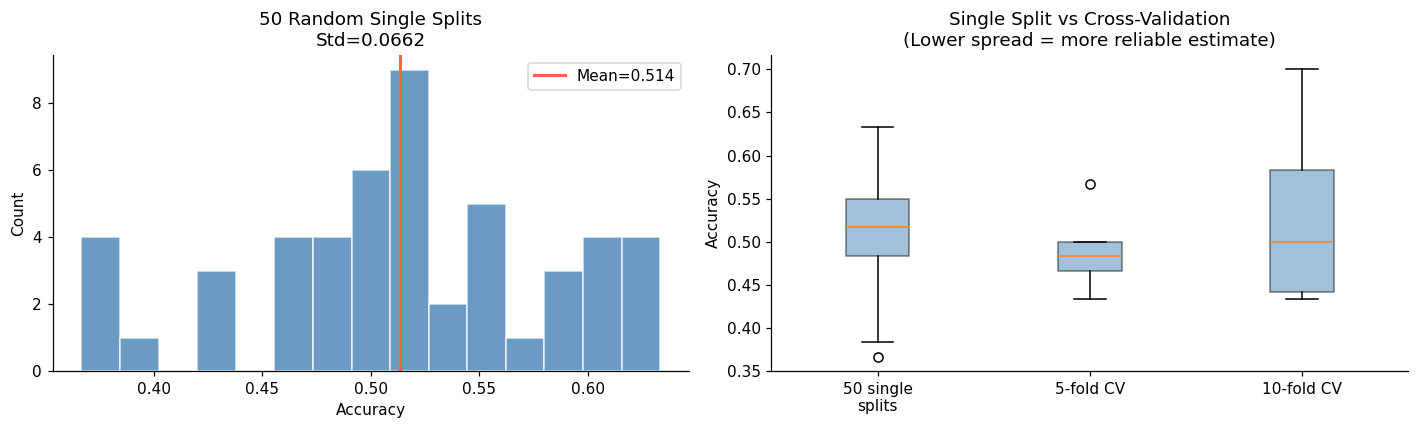

Single split: mean=0.5137, std=0.0662
5-fold CV:    mean=0.4900,  std=0.0442
10-fold CV:   mean=0.5300,  std=0.0983


In [10]:
# Demonstrate variance of single split vs k-fold CV
rng = np.random.default_rng(4)
n = 300
X_cv, y_cv = make_classification(
    n_samples=n, n_features=5, n_informative=3,
    n_redundant=1, random_state=4
)

model = LogisticRegression(max_iter=500, random_state=0)

# 50 random single splits
single_scores = []
for seed in range(50):
    Xtr, Xte, ytr, yte = train_test_split(X_cv, y_cv, test_size=0.2, random_state=seed)
    model.fit(Xtr, ytr)
    single_scores.append(model.score(Xte, yte))

# 5-fold CV (repeated 10 times)
cv5_scores = cross_val_score(model, X_cv, y_cv, cv=5, scoring='accuracy')
cv10_scores = cross_val_score(model, X_cv, y_cv, cv=10, scoring='accuracy')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(single_scores, bins=15, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(np.mean(single_scores), color='tomato', linewidth=2,
                label=f'Mean={np.mean(single_scores):.3f}')
axes[0].set_xlabel('Accuracy')
axes[0].set_ylabel('Count')
axes[0].set_title(f'50 Random Single Splits\nStd={np.std(single_scores):.4f}')
axes[0].legend()

axes[1].boxplot(
    [single_scores, cv5_scores, cv10_scores],
    labels=['50 single\nsplits', '5-fold CV', '10-fold CV'],
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.5)
)
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Single Split vs Cross-Validation\n(Lower spread = more reliable estimate)')

plt.tight_layout()
plt.show()

print(f'Single split: mean={np.mean(single_scores):.4f}, std={np.std(single_scores):.4f}')
print(f'5-fold CV:    mean={cv5_scores.mean():.4f},  std={cv5_scores.std():.4f}')
print(f'10-fold CV:   mean={cv10_scores.mean():.4f},  std={cv10_scores.std():.4f}')

### 9. Class Imbalance

#### Theory

In failure detection, failures are rare — typically 1–5% of observations. A naive classifier that always predicts "no failure" achieves 95–99% **accuracy** while being completely useless.

**Strategies to handle class imbalance**:

| Strategy | Idea |
|---|---|
| `class_weight='balanced'` | Upweight minority class in the loss |
| Oversampling (SMOTE) | Synthetically generate minority class samples |
| Undersampling | Remove majority class samples |
| Threshold tuning | Shift decision boundary from 0.5 to lower value |

**Appropriate metrics**: use **Precision, Recall, F1, AUC-ROC** — not accuracy.  
In failure detection specifically, **Recall** (catching real failures) matters most:
$$\text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}}$$
Missing a real failure (FN) is far more costly than a false alarm (FP).

In [11]:
from sklearn.metrics import classification_report, roc_auc_score

rng = np.random.default_rng(11)
n_total, failure_rate = 2000, 0.04
n_fail = int(n_total * failure_rate)
n_norm = n_total - n_fail

# Two informative features with class separation
X_norm = rng.normal([0, 0], [1, 1], (n_norm, 2))
X_fail = rng.normal([2, 2], [1, 1], (n_fail, 2))
X_imb  = np.vstack([X_norm, X_fail])
y_imb  = np.array([0]*n_norm + [1]*n_fail)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_imb, y_imb, test_size=0.3, stratify=y_imb, random_state=0
)

# Model 1: unweighted
lr_unw = LogisticRegression(max_iter=500)
lr_unw.fit(X_tr, y_tr)

# Model 2: class_weight='balanced'
lr_bal = LogisticRegression(max_iter=500, class_weight='balanced')
lr_bal.fit(X_tr, y_tr)

# Model 3: oversample minority (simple random oversampling)
fail_idx  = np.where(y_tr == 1)[0]
over_idx  = resample(fail_idx, replace=True, n_samples=len(y_tr) - 2*len(fail_idx), random_state=0)
X_over    = np.vstack([X_tr, X_tr[over_idx]])
y_over    = np.concatenate([y_tr, y_tr[over_idx]])
lr_over   = LogisticRegression(max_iter=500)
lr_over.fit(X_over, y_over)

print(f'Class distribution: {n_norm} normal, {n_fail} failure ({failure_rate*100:.0f}%)')
print('\n--- Unweighted ---')
print(classification_report(y_te, lr_unw.predict(X_te), target_names=['Normal','Failure'], digits=3))
print('--- Balanced weights ---')
print(classification_report(y_te, lr_bal.predict(X_te), target_names=['Normal','Failure'], digits=3))
print('--- Oversampling ---')
print(classification_report(y_te, lr_over.predict(X_te), target_names=['Normal','Failure'], digits=3))

Class distribution: 1920 normal, 80 failure (4%)

--- Unweighted ---
              precision    recall  f1-score   support

      Normal      0.991     0.991     0.991       576
     Failure      0.792     0.792     0.792        24

    accuracy                          0.983       600
   macro avg      0.891     0.891     0.891       600
weighted avg      0.983     0.983     0.983       600

--- Balanced weights ---
              precision    recall  f1-score   support

      Normal      0.998     0.925     0.960       576
     Failure      0.348     0.958     0.511        24

    accuracy                          0.927       600
   macro avg      0.673     0.942     0.736       600
weighted avg      0.972     0.927     0.942       600

--- Oversampling ---
              precision    recall  f1-score   support

      Normal      0.998     0.920     0.958       576
     Failure      0.333     0.958     0.495        24

    accuracy                          0.922       600
   macro avg 

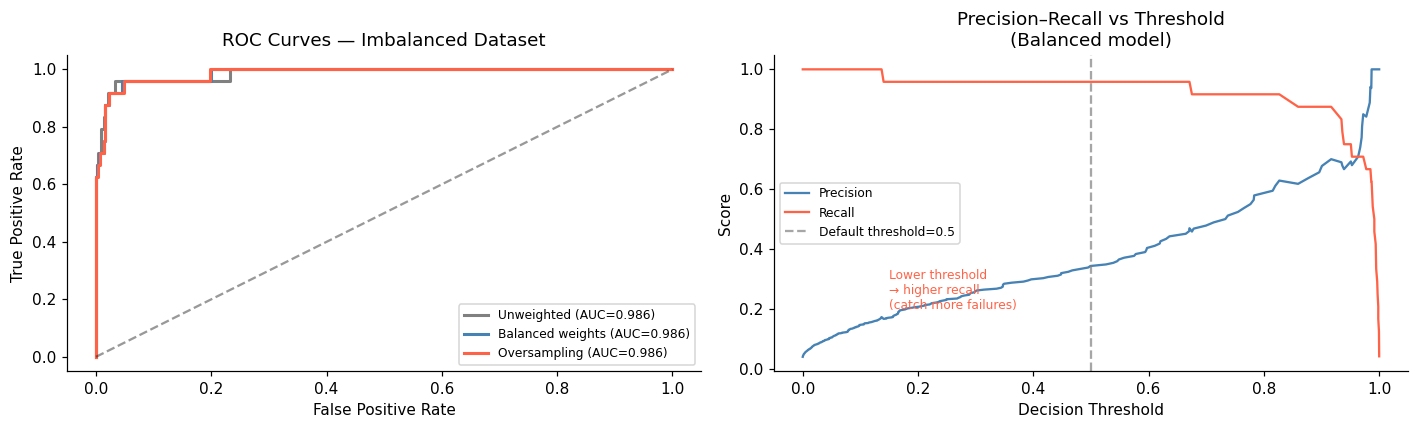

In [12]:
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ROC curves
for model, name, col in [
    (lr_unw,  'Unweighted', 'gray'),
    (lr_bal,  'Balanced weights', 'steelblue'),
    (lr_over, 'Oversampling', 'tomato')
]:
    prob = model.predict_proba(X_te)[:,1]
    fpr, tpr, _ = roc_curve(y_te, prob)
    auc = roc_auc_score(y_te, prob)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=col, linewidth=2)

axes[0].plot([0,1],[0,1],'k--',alpha=0.4)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — Imbalanced Dataset')
axes[0].legend(fontsize=8)

# Recall vs threshold for balanced model
from sklearn.metrics import precision_recall_curve
prob_bal = lr_bal.predict_proba(X_te)[:,1]
prec, rec, thres = precision_recall_curve(y_te, prob_bal)
axes[1].plot(thres, prec[:-1], color='steelblue', label='Precision')
axes[1].plot(thres, rec[:-1],  color='tomato',    label='Recall')
axes[1].axvline(0.5, color='gray', linestyle='--', alpha=0.7, label='Default threshold=0.5')
axes[1].set_xlabel('Decision Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision–Recall vs Threshold\n(Balanced model)')
axes[1].legend(fontsize=8)
axes[1].text(0.15, 0.2, 'Lower threshold\n→ higher recall\n(catch more failures)',
             fontsize=8, color='tomato')

plt.tight_layout()
plt.show()

### 10. Learning Curves

#### Theory

A **learning curve** plots train and validation error as a function of training set size $n$. It is one of the most useful diagnostic tools in ML.

**How to read a learning curve**:

| Pattern | Diagnosis | Remedy |
|---|---|---|
| Both errors high and converge | Underfitting (high bias) | Use a more complex model |
| Large gap between train and val error | Overfitting (high variance) | More data, regularisation, simpler model |
| Val error still decreasing | More data will help | Collect more training data |
| Val error plateaued | More data won't help | Improve model or features |

As $n \to \infty$:
- Train error **increases** (harder to fit more data perfectly)
- Validation error **decreases** (more data reduces variance)
- Both converge to the **irreducible error + bias**

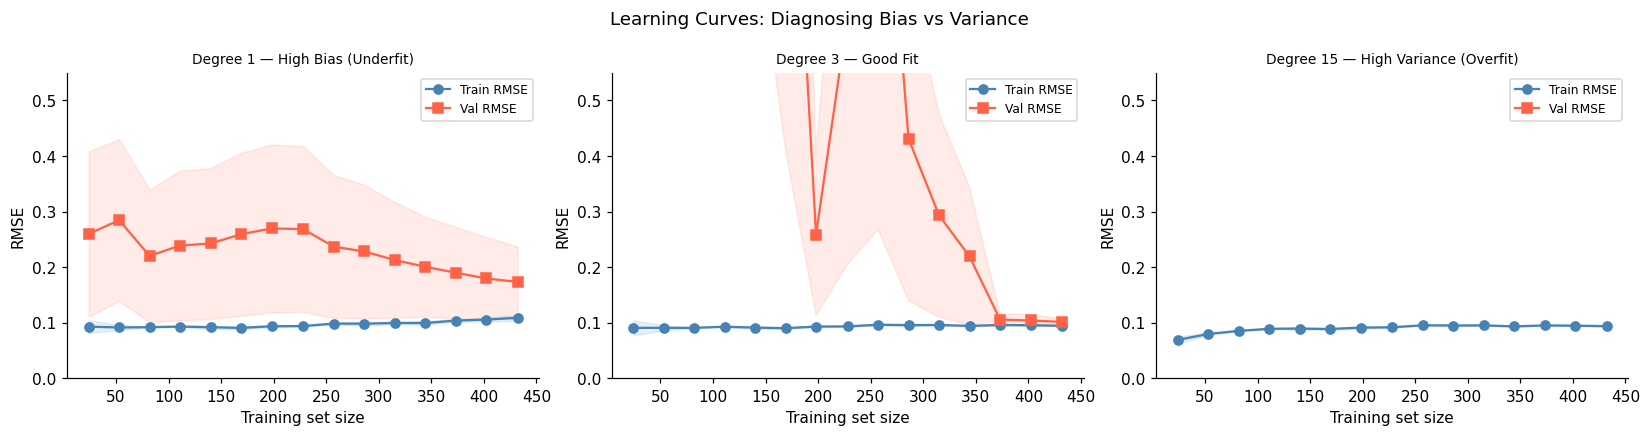

In [13]:
rng = np.random.default_rng(13)
n_total = 600
X_lc = np.sort(rng.uniform(0, 1, n_total)).reshape(-1, 1)
y_lc = true_fn(X_lc.ravel()) + rng.normal(0, 0.1, n_total)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

configs = [
    (make_pipeline(PolynomialFeatures(1), LinearRegression()), 'Degree 1 — High Bias (Underfit)'),
    (make_pipeline(PolynomialFeatures(3), LinearRegression()), 'Degree 3 — Good Fit'),
    (make_pipeline(PolynomialFeatures(15), LinearRegression()), 'Degree 15 — High Variance (Overfit)'),
]

train_sizes_abs = np.linspace(0.05, 0.9, 15)

for ax, (model, title) in zip(axes, configs):
    tr_sizes, tr_scores, val_scores = learning_curve(
        model, X_lc, y_lc,
        train_sizes=train_sizes_abs,
        cv=5, scoring='neg_mean_squared_error',
        n_jobs=-1
    )
    tr_rmse  = np.sqrt(-tr_scores.mean(axis=1))
    val_rmse = np.sqrt(-val_scores.mean(axis=1))
    tr_std   = np.sqrt(-tr_scores).std(axis=1)
    val_std  = np.sqrt(-val_scores).std(axis=1)

    ax.plot(tr_sizes, tr_rmse,  'o-', color='steelblue', label='Train RMSE')
    ax.plot(tr_sizes, val_rmse, 's-', color='tomato',    label='Val RMSE')
    ax.fill_between(tr_sizes, tr_rmse-tr_std,   tr_rmse+tr_std,   alpha=0.12, color='steelblue')
    ax.fill_between(tr_sizes, val_rmse-val_std, val_rmse+val_std, alpha=0.12, color='tomato')
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Training set size')
    ax.set_ylabel('RMSE')
    ax.set_ylim(0, 0.55)
    ax.legend(fontsize=8)

plt.suptitle('Learning Curves: Diagnosing Bias vs Variance', fontsize=12)
plt.tight_layout()
plt.show()

### Summary

| Concept | Key equation / tool | Practical implication |
|---|---|---|
| Empirical risk | $\hat{R}(f) = \frac{1}{n}\sum \ell(\hat{y}_i, y_i)$ | What we optimise; generalisation is the real goal |
| Loss functions | L2, L1, Huber, cross-entropy | Choice depends on noise, outliers, asymmetry |
| Underfitting | High train + test error | Increase model complexity |
| Overfitting | Low train, high test error | Regularise, get more data, simplify |
| Bias–variance | $\text{Error} = \text{Bias}^2 + \text{Variance} + \sigma^2$ | Fundamental tradeoff; cannot eliminate both |
| Regularisation | Ridge (L2), Lasso (L1) | Controls variance; Lasso gives sparsity |
| Curse of dimensionality | Sparsity grows with $d$ | Remove uninformative features |
| Feature scaling | Z-score or min-max | Always fit scaler on train only |
| Cross-validation | $k$-fold CV | More reliable than a single split |
| Class imbalance | Recall, F1, AUC | Accuracy misleads; use balanced weights or resampling |
| Learning curves | Train vs val error vs $n$ | Diagnose bias/variance and data sufficiency |

### Further Reading
- ESL Chapter 2 (Overview), Chapter 7 (Model Selection), Chapter 3 (Linear Methods) — Hastie et al. (2009)
- PRML Chapter 3 (Linear Models) — Bishop (2006)
- Domingos, P. (2012). [A Few Useful Things to Know About Machine Learning](https://dl.acm.org/doi/10.1145/2347736.2347755). *CACM*, 55(10), 78–87.